# Exploratory Data Analysis

With the objective of understanding the data structure regarding the STAR-TPM Glioblastoma gene expression dataset, this present stage of the investigation will follow the standard *Exploratory Data Analysis* methodology for uncovering the contents of the dataset.

The following code will help us understand:

- Number of samples (patients)
- Number of variables (genes)
- Available clinical variables

In [13]:
import pandas as pd

df = pd.read_csv('../data/star_data/TCGA-GBM.star_tpm.tsv', sep='\t')

# 1. Count the number of samples
num_samples = len(df)

# 2. Count the total number of variables
num_variables = len(df.columns)

# 3. Identify and count available clinical variables
# Note: In UCSC Xena datasets, gene expression columns are usually numeric, 
# while clinical variables are often non-numeric or specifically labeled.
clinical_vars = df.select_dtypes(exclude=['float64', 'int64']).columns.tolist()
num_clinical_vars = len(clinical_vars)

print(f"Number of samples: {num_samples}")
print(f"Total number of variables: {num_variables}")
print(f"Number of clinical variables: {num_clinical_vars}")
print(f"Clinical variables found: {clinical_vars}")

df.T
df


Number of samples: 60660
Total number of variables: 176
Number of clinical variables: 1
Clinical variables found: ['Ensembl_ID']


,Ensembl_ID,TCGA-27-2521-01A,TCGA-19-1390-01A,TCGA-27-1830-01A,TCGA-32-1970-01A,TCGA-06-0190-01A,TCGA-06-0190-02A,TCGA-02-2486-01A,TCGA-14-0790-01B,TCGA-14-0789-01A,...,TCGA-27-2519-01A,TCGA-26-5134-01A,TCGA-06-0675-11A,TCGA-06-1804-01A,TCGA-14-1829-01A,TCGA-06-0184-01A,TCGA-32-2638-01A,TCGA-12-3652-01A,TCGA-28-5209-01A,TCGA-76-4925-01A
0,ENSG00000000003.15,2.783163,4.502031,6.164816,5.940879,6.149881,5.386263,6.818908,6.559516,5.845139,...,6.228588,5.399151,3.284174,5.722884,7.908395,6.523104,6.747138,6.949359,6.377500,6.316540
1,ENSG00000000005.6,1.203076,0.066537,0.673918,0.899794,0.366588,1.093695,0.659377,0.840926,0.092884,...,1.225892,0.585347,0.388796,0.412727,3.007052,0.505078,1.388906,0.425674,0.626392,0.496718
2,ENSG00000000419.13,6.869697,5.901299,6.227456,5.746119,6.351695,6.433978,6.693888,6.274832,5.687909,...,6.574426,5.576350,5.762248,6.065012,7.120749,6.106935,6.559345,6.912564,6.399855,7.415961
3,ENSG00000000457.14,2.990828,2.863225,2.859135,2.728552,2.551934,2.350441,2.794790,2.699751,2.529646,...,2.489389,2.603976,2.501261,2.616640,2.589883,2.350271,2.846473,2.152768,2.952129,2.950095
4,ENSG00000000460.17,2.421937,2.992080,2.234685,2.321986,2.991481,2.697752,2.018385,2.290572,1.792730,...,1.942796,2.511392,0.914488,2.080009,2.832566,1.948788,2.313217,2.616734,2.900258,2.785320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60655,ENSG00000288669.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.084064,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60656,ENSG00000288670.1,3.457148,3.921408,3.793365,3.802255,2.827270,2.643764,3.042872,3.731009,3.275856,...,3.734905,3.359746,5.106717,3.510291,2.153773,2.798693,3.721012,2.029877,3.458408,4.119049
60657,ENSG00000288671.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60658,ENSG00000288674.1,0.022048,0.020769,0.158725,0.058663,0.025454,0.114900,0.000000,0.017352,0.071763,...,0.085289,0.106750,0.076149,0.081476,0.000000,0.072449,0.093695,0.037453,0.070527,0.097746


As we can see, there are $n=60,660$ patient gene expression samples in the dataset, with $p=176$ variables. The only clinical variable that was found in the dataset is ´Ensembl_ID´, which pertains to the unique identifier for each of the $n$ gene expressions, therefore, we have a total of 175 gene expression variables to use in the present investigation.

According to the National Cancer Institute pertaining to the U.S. Department of Health and Human Services, the creation of this unique sequence expression was derived from the [mRNA Analysis Pipeline](https://docs.gdc.cancer.gov/Data/Bioinformatics_Pipelines/Expression_mRNA_Pipeline/), which is a quantification analysis pipeline that measures gene level expression with the [STAR](https://github.com/alexdobin/STAR/blob/master/doc/STARmanual.pdf) aligner code, which uses TPM (Transcripts Per Million) values to map RNA sequence reads. This method is creates reliable and normalized measures for gene expressions, which are optimal for visualization via unsupervised learning methods accross samples. 

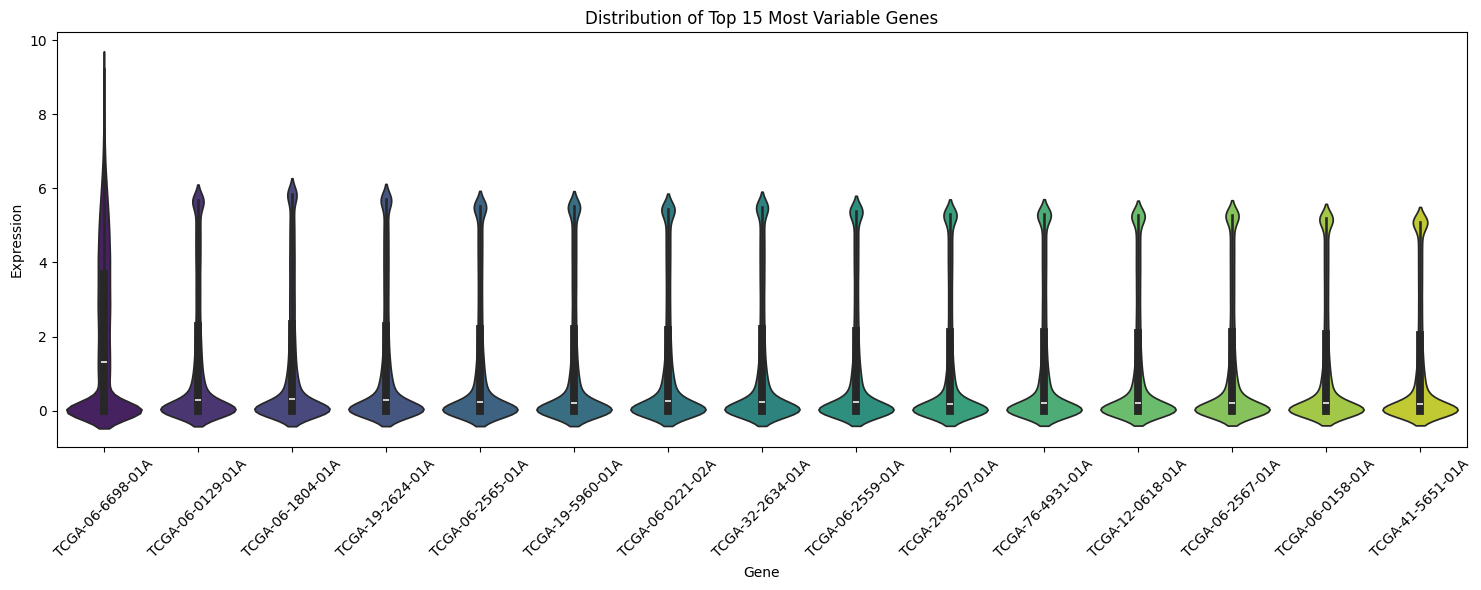

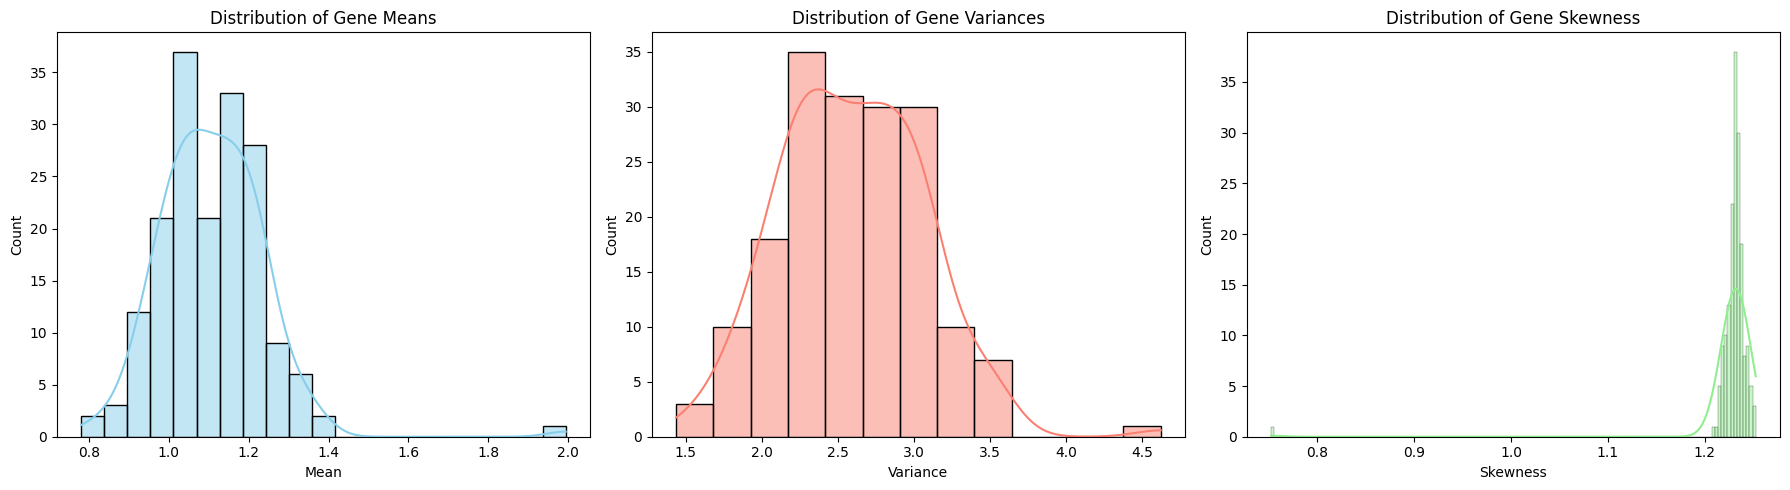

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew


def process_gene_data(df):
    """
    Cleans data, filters for high-variance genes, and plots distribution statistics.
    """
    # 1. Handle Missing Values
    # We'll use median imputation to stay robust against outliers
    df_cleaned = df.fillna(df.median())

    # 2. Handle Potential Outliers
    # Using the IQR method to clip extreme values (winsorization) 
    # This keeps the data points but prevents them from distorting the variance too much.
    Q1 = df_cleaned.quantile(0.25)
    Q3 = df_cleaned.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned.clip(lower=lower_bound, upper=upper_bound, axis=1)

    # 3. Calculate Top K Variance Filter (Top 15)
    variances = df_cleaned.var().sort_values(ascending=False)
    top_15_genes = variances.head(15).index
    df_top_15 = df_cleaned[top_15_genes]

    # 4. Violin Plot for Top 15 Most Variable Genes
    plt.figure(figsize=(15, 6))
    # Melting the dataframe makes it compatible with Seaborn's categorical plotting
    df_melted = df_top_15.melt(var_name='Gene', value_name='Expression')
    sns.violinplot(data=df_melted, x='Gene', y='Expression', hue='Gene', palette='viridis', legend=False)
    plt.xticks(rotation=45)
    plt.title('Distribution of Top 15 Most Variable Genes')
    plt.tight_layout()
    plt.show()

    # 5. Calculate Global Statistics for all 175 genes
    stats_df = pd.DataFrame({
        'Mean': df_cleaned.mean(),
        'Variance': df_cleaned.var(),
        'Skewness': df_cleaned.apply(lambda x: skew(x))
    })

    # 6. Plot Histograms for Mean, Variance, and Skewness
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Mean Histogram
    sns.histplot(stats_df['Mean'], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of Gene Means')

    # Variance Histogram
    sns.histplot(stats_df['Variance'], kde=True, ax=axes[1], color='salmon')
    axes[1].set_title('Distribution of Gene Variances')

    # Skewness Histogram
    sns.histplot(stats_df['Skewness'], kde=True, ax=axes[2], color='lightgreen')
    axes[2].set_title('Distribution of Gene Skewness')

    plt.tight_layout()
    plt.show()

    return stats_df

# Execute the analysis
stats_summary = process_gene_data(df)
